# **Task 1**
Determining heart and non heart images.

In [ ]:
!pip install tensorflow


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from pandas import DataFrame
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

h='/content/drive/MyDrive/ds-1/heart'
h1='/content/drive/MyDrive/ds-1/non-heart'

w=25
b=25
o=9
pp=(8,8)
cb=(2,2)


def extract_hog_features(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (w,b))
    fd = hog(image, orientations=o, pixels_per_cell=pp,
             cells_per_block=cb, visualize=False, channel_axis=None)
    return fd



a=[]
target=[]

for root,_,files in os.walk(h):
  for file in files :
    if file.endswith(('.png','.jpg','.jpeg')):
      img_path=os.path.join(root,file)
      features=extract_hog_features(img_path)
      a.append(features)
      target.append('heart')

for root,_,files in os.walk(h1):
  for file in files:
    if file.endswith(('.png', '.jpg', '.jpeg')):
      img_path=os.path.join(root, file)
      features=extract_hog_features(img_path)
      a.append(features)
      target.append('non-heart')

df=DataFrame(a)
df['class']=target
df.head()

,0,1,2,3,4,5,6,7,8,9,...,135,136,137,138,139,140,141,142,143,class
0,0.002356,0.001020,0.000645,0.031779,0.002282,0.00102,0.000000,0.0,0.0,0.287970,...,0.204627,0.218977,0.072172,0.079348,0.136890,0.076898,0.064649,0.182894,0.087670,heart
1,0.000000,0.000000,0.004032,0.047234,0.002060,0.00000,0.000000,0.0,0.0,0.306145,...,0.248276,0.120396,0.135507,0.071300,0.120251,0.151497,0.062215,0.236576,0.248276,heart
2,0.001803,0.000000,0.034416,0.000000,0.001352,0.00000,0.000000,0.0,0.0,0.282293,...,0.187513,0.184526,0.190705,0.041344,0.195193,0.028598,0.108505,0.108192,0.126570,heart
3,0.001009,0.000000,0.001427,0.041526,0.001009,0.00000,0.000714,0.0,0.0,0.307855,...,0.254367,0.160502,0.118530,0.109994,0.101579,0.140319,0.059374,0.154678,0.123377,heart
4,0.000919,0.054861,0.000650,0.000000,0.003217,0.00000,0.000000,0.0,0.0,0.286151,...,0.129286,0.250829,0.175616,0.020553,0.164423,0.013359,0.092398,0.156006,0.117220,heart


1> Here the code begins by importing various Python libraries necessary for processing data, extracting features, and building a machine learning model.

2> **HOG Feature Extraction**

In the next step we have used HOG for feature extraction of the image.
function used:" extract_hog_features".

Here the image is read in GRAYSCALE as it is the part of image preprocessing.

3> next step we are doing data collection and labeling.

In [ ]:
df['class'].unique()

array(['heart', 'non-heart'], dtype=object)

now we're doing a quick check to inspect the unique class labels in your dataset

In [ ]:
df['class']=df['class'].replace({'heart':1, 'non-heart':0})
df.head()

<ipython-input-4-18fd7f022c78>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['class']=df['class'].replace({'heart':1, 'non-heart':0})


,0,1,2,3,4,5,6,7,8,9,...,135,136,137,138,139,140,141,142,143,class
0,0.002356,0.001020,0.000645,0.031779,0.002282,0.00102,0.000000,0.0,0.0,0.287970,...,0.204627,0.218977,0.072172,0.079348,0.136890,0.076898,0.064649,0.182894,0.087670,1
1,0.000000,0.000000,0.004032,0.047234,0.002060,0.00000,0.000000,0.0,0.0,0.306145,...,0.248276,0.120396,0.135507,0.071300,0.120251,0.151497,0.062215,0.236576,0.248276,1
2,0.001803,0.000000,0.034416,0.000000,0.001352,0.00000,0.000000,0.0,0.0,0.282293,...,0.187513,0.184526,0.190705,0.041344,0.195193,0.028598,0.108505,0.108192,0.126570,1
3,0.001009,0.000000,0.001427,0.041526,0.001009,0.00000,0.000714,0.0,0.0,0.307855,...,0.254367,0.160502,0.118530,0.109994,0.101579,0.140319,0.059374,0.154678,0.123377,1
4,0.000919,0.054861,0.000650,0.000000,0.003217,0.00000,0.000000,0.0,0.0,0.286151,...,0.129286,0.250829,0.175616,0.020553,0.164423,0.013359,0.092398,0.156006,0.117220,1


we’re converting our categorical labels into numerical format, which is a key preprocessing step before feeding data into a machine learning model.

In [ ]:
x=df.drop('class', axis=1).values
y=df['class'].values

This step is separating our features (x-the feature matrix) and labels (y-the target vector).

In [ ]:
from sklearn.model_selection import KFold, StratifiedKFold

Here we're bringing in tools for cross-validation, specifically KFold and StratifiedKFold, which are used to evaluate our model more reliably.

In [ ]:
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.25, stratify=y ,random_state=42)

This line splits your dataset into a training set and a test set. 25% of the data will be reserved for testing, and 75% will be used to train.

In [ ]:
c=SVC(kernel='linear', random_state=42)
c.fit(x_train, y_train)

y_pred=c.predict(x_test)

Training the Support Vector Machine (SVM) Model

This line creates an instance of a Support Vector Classifier (SVC) model, assigning it to the variable c.

In [ ]:
print(confusion_matrix(y_test, y_pred))

[[231   0]
 [  0  55]]


This line prints the confusion matrix, which compares our model's predicted labels (y_pred) with the actual labels (y_test) from the test set.

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       231
           1       1.00      1.00      1.00        55

    accuracy                           1.00       286
   macro avg       1.00      1.00      1.00       286
weighted avg       1.00      1.00      1.00       286



Now we're taking out our evaluation with the classification_report, which gives us a full summary of key performance metrics for our classifier.

In [ ]:
from sklearn.model_selection import cross_validate
d=cross_validate(c,x_train,y_train, cv=5)
s=sum(d['test_score'])/len(d['test_score'])
print(s)

1.0


Here we are doing five fold cross validation to evaluate the performance of the trained SVC model.

In [ ]:
from keras import utils

For data preparation, conversion, and neural network management the utils module from Keras is used here.

**Reshaping and preprocessing data for CNN**

In [ ]:
num_features = x_train.shape[1]
height=w
width=b
channels=1

r_d1=x_train.shape[1]
r_d2=int(np.sqrt(num_features/channels))
r_d3=r_d2
r_d4=channels

x_train_reshape=x_train.reshape((x_train.shape[0], r_d2, r_d3, r_d4))

r_d1_t=x_test.shape[0]
x_test_reshape=x_test.reshape((x_test.shape[0], r_d2,r_d3, r_d4))

x_train_reshape =x_train_reshape.astype('float32')
x_test_reshape =x_test_reshape.astype('float32')

x_train_reshape /= 255
x_test_reshape /= 255

now we're prepping our data for a Convolutional Neural Network (CNN).
In this preprocessing stage, I reshaped the extracted HOG features into a 4D format for CNNs.I also normalized the feature values to the [0,1] range and converted the data type to float32, ensuring compatibility and stability during training.

In [ ]:
y_train_cat=utils.to_categorical(y_train, 2)
y_test_cat=utils.to_categorical(y_test, 2)
print(y_train_cat)


[[1. 0.]
 [1. 0.]
 [1. 0.]
 ...
 [1. 0.]
 [1. 0.]
 [1. 0.]]


To prepare the class labels for deep learning, I converted the binary class labels (0 for non-heart and 1 for heart) into a one-hot encoded format using utils.to_categorical() from Keras.

In [ ]:
import keras
import tensorflow as tf
from sklearn.model_selection import cross_val_score

now we’re bringing in Keras and TensorFlow to build and train a deep learning model, and at the same time, we're importing cross_val_score from sklearn to perform cross-validation later.

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model=tf.keras.models.Sequential()


model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(r_d2, r_d3, r_d4)))
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))
model.add(tf.keras.layers.Dropout(0.25))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(2, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


I constructed a Convolutional Neural Network using Keras’ Sequential API to classify heart and non-heart images based on extracted HOG features.It consistof two convolutional layers followed by max pooling and dropout for regularization. After flattening the output, a dense layer with 128 neurons is added to capture complex patterns, with another dropout layer to further prevent overfitting. The final output layer uses softmax activation to predict the probability of each class

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 10, 10, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,490 (294.88 KB)

 Trainable params: 75,490 (294.88 KB)

 Non-trainable params: 0 (0.00 B)

This gives us a detailed overview of your CNN architecture

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In this line we are preparing our CNN model for training by specifying how it should learn and evaluate.

In [ ]:

model.fit(x_train_reshape, y_train_cat, batch_size=128, epochs=10, verbose=1, validation_data=(x_test_reshape, y_test_cat))



Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 801ms/step - accuracy: 0.6093 - loss: 0.6844 - val_accuracy: 0.8077 - val_loss: 0.6390
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8025 - loss: 0.6142 - val_accuracy: 0.8077 - val_loss: 0.5170
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8030 - loss: 0.5107 - val_accuracy: 0.8077 - val_loss: 0.5137
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8083 - loss: 0.5103 - val_accuracy: 0.8077 - val_loss: 0.4904
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7910 - loss: 0.5229 - val_accuracy: 0.8077 - val_loss: 0.4961
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8084 - loss: 0.5017 - val_accuracy: 0.8077 - val_loss: 0.4903
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8181 - loss: 0.4785 - val_accuracy: 0.8077 - val_loss: 0.4908
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8195 - loss: 0.4813 - val_accuracy: 0.8077 - val_loss: 0.489

This line initiates model training, where the CNN updates its internal weights over multiple passes through the data.

In [ ]:
loss, accuracy = model.evaluate(x_test_reshape, y_test_cat, verbose=0)
print('Loss: ', loss,'\nAcc: ', accuracy)

Loss:  0.49008166790008545 
Acc:  0.807692289352417


To evaluate the performance of the trained CNN model the built-in function in keras is used to access the performance of the model where SVM execution time was lesser and CNN performance is based on vigerous training.

In [ ]:
pred=model.predict(x_test_reshape)
class_y=np.argmax(y_test_cat, axis=1)
class_x=np.argmax(pred, axis=1)

print(classification_report(class_x, class_y))



9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
              precision    recall  f1-score   support

           0       1.00      0.81      0.89       286
           1       0.00      0.00      0.00         0

    accuracy                           0.81       286
   macro avg       0.50      0.40      0.45       286
weighted avg       1.00      0.81      0.89       286



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In this line of code we are using the trained CNN model to make predictions on the test data(x_test_reshape) and evaluate the quality of those prediction

In [ ]:
from sklearn.model_selection import KFold, StratifiedKFold
k=KFold(n_splits=5)
kf=StratifiedKFold(n_splits=5)
k.get_n_splits(x_train_reshape,class_x)
kf.get_n_splits(class_y, class_x)
print(k)

i=1
for train_index, test_index in k.split(x_train_reshape):
    print('\nFold '+str(i)+':')
    print('TRAIN INDEXES:', train_index)
    print('TEST INDEXES:', test_index)
    X_train, X_test = x_train_reshape[train_index], x_train_reshape[test_index]
    y_train, y_test = y_train_cat[train_index], y_train_cat[test_index]
    i+=1

KFold(n_splits=5, random_state=None, shuffle=False)

Fold 1:
TRAIN INDEXES: [172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189
 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207
 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225
 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243
 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261
 262 263 264 265 266 267 268 269 270 271 272 273 274 275 276 277 278 279
 280 281 282 283 284 285 286 287 288 289 290 291 292 293 294 295 296 297
 298 299 300 301 302 303 304 305 306 307 308 309 310 311 312 313 314 315
 316 317 318 319 320 321 322 323 324 325 326 327 328 329 330 331 332 333
 334 335 336 337 338 339 340 341 342 343 344 345 346 347 348 349 350 351
 352 353 354 355 356 357 358 359 360 361 362 363 364 365 366 367 368 369
 370 371 372 373 374 375 376 377 378 379 380 381 382 383 384 385 386 387
 388 389 390 391 392 393 394 395 396 397 398 399

 This is a setting of 5-fold cross-validation, here the dataset will be split into 5 equal parts, and the model will train on 4 parts and test on the remaining one — repeating this 5 times with a different test set each time.


**Observation on task 1 experiment**
I have noticed that

1.   CNN average running time is high.
2.   requires much data.
3.  svm is a better classifier
4.  SVM performs well on small data.





# **Conclusion for task 1**
 Comapring Support Vector Machine and the convolutional model,SVM works much better
  i.e generalise better to the test data leading to better results across various metrics.

  Instant results were displayed accurately.
  
  Can be used for problem determination and is dependent of feature training.

#**Task 2**
*   Segration of open and close heart images
*   Model chosen: Support Vector Machine.



In [ ]:
h2='/content/drive/MyDrive/ds-1/heart/closed'
h3='/content/drive/MyDrive/ds-1/heart/open'

w=25
b=25
o=9
pp=(8,8)
cb=(2,2)


def extract_hog_features(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (w,b))
    fd = hog(image, orientations=o, pixels_per_cell=pp,
             cells_per_block=cb, visualize=False, channel_axis=None)
    return fd



a=[]
target=[]

for root,_,files in os.walk(h2):
  for file in files :
    if file.endswith(('.png','.jpg','.jpeg')):
      img_path=os.path.join(root,file)
      features=extract_hog_features(img_path)
      a.append(features)
      target.append('close')

for root,_,files in os.walk(h3):
  for file in files:
    if file.endswith(('.png', '.jpg', '.jpeg')):
      img_path=os.path.join(root, file)
      features=extract_hog_features(img_path)
      a.append(features)
      target.append('open')

df=DataFrame(a)
df['class']=target
df.head()

,0,1,2,3,4,5,6,7,8,9,...,135,136,137,138,139,140,141,142,143,class
0,0.002356,0.001020,0.000645,0.031779,0.002282,0.00102,0.000000,0.0,0.0,0.287970,...,0.204627,0.218977,0.072172,0.079348,0.136890,0.076898,0.064649,0.182894,0.087670,close
1,0.000000,0.000000,0.004032,0.047234,0.002060,0.00000,0.000000,0.0,0.0,0.306145,...,0.248276,0.120396,0.135507,0.071300,0.120251,0.151497,0.062215,0.236576,0.248276,close
2,0.001803,0.000000,0.034416,0.000000,0.001352,0.00000,0.000000,0.0,0.0,0.282293,...,0.187513,0.184526,0.190705,0.041344,0.195193,0.028598,0.108505,0.108192,0.126570,close
3,0.001009,0.000000,0.001427,0.041526,0.001009,0.00000,0.000714,0.0,0.0,0.307855,...,0.254367,0.160502,0.118530,0.109994,0.101579,0.140319,0.059374,0.154678,0.123377,close
4,0.000919,0.054861,0.000650,0.000000,0.003217,0.00000,0.000000,0.0,0.0,0.286151,...,0.129286,0.250829,0.175616,0.020553,0.164423,0.013359,0.092398,0.156006,0.117220,close


Similarly to task 1 even for task 2 we have defined function for HOG feature extraction and then collecting and labelling the data.

In [ ]:
df['class']=df['class'].replace({'close':0, 'open':1})
df['class'].unique()

<ipython-input-24-d904ba7c815e>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['class']=df['class'].replace({'close':0, 'open':1})


array([0, 1])

Here categorical labels are replaced by numerical ones [0,1] and then unique feature is displayed.

In [ ]:
x=df.drop(df['class'], axis=1).values
y=df['class'].values

Here we are seperating the feature matrix(x) and the labels(y)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.25, random_state=42)
c=SVC(kernel='linear', random_state=42)
c.fit(x_train, y_train)
y_pred=c.predict(x_test)

Here we are splitting the data for training(75%) and testing(25%).Then Support vector classifier is used for classification and is assigned to c.

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        40

    accuracy                           1.00        55
   macro avg       1.00      1.00      1.00        55
weighted avg       1.00      1.00      1.00        55



This is the classification report, showing the performance metrics of our classifier.

In [ ]:
print(confusion_matrix(y_test, y_pred))

[[15  0]
 [ 0 40]]


This shows the comparison between the actual labels and the predicted labels.

In [ ]:
from sklearn.model_selection import cross_validate
d= cross_validate(c, x, y, cv=5)
s=sum(d['test_score'])/len(d['test_score'])
print(s)

1.0


Here we are doing five fold cross validation to evaluate the performance of the trained SVC model.


# **Observation from task 2**


1.   Svm classifier performed in the way expexted
2.   Accuracy, precision and recall is 1
3.   True negatives and false negatives were not
     recorded
4.   Problem identification was done in an expected way


#**Task 3**
To imporve the result from previous experiment by means of image/data augmentation by use of transformer learning


In [ ]:

import os
from PIL import Image
import numpy as np


h2 = '/content/drive/MyDrive/ds-1/heart/closed'
h3= '/content/drive/MyDrive/ds-1/heart/open'

def load_images_from_folder(folder_path, image_size=(224, 224)):
    images = []
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        try:
            img = Image.open(file_path).convert('RGB')
            img = img.resize(image_size)
            images.append(np.array(img))
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    return np.array(images)

closed_images = load_images_from_folder(h2)
open_images = load_images_from_folder(h3)

print(f"Closed heart images: {closed_images.shape}")
print(f"Open heart images: {open_images.shape}")


Closed heart images: (80, 224, 224, 3)
Open heart images: (138, 224, 224, 3)


In [ ]:
import numpy as np

closed_labels = np.zeros(len(closed_images))   # Label 0 for "closed"
open_labels = np.ones(len(open_images))        # Label 1 for "open"

images = np.concatenate((closed_images, open_images), axis=0)
labels = np.concatenate((closed_labels, open_labels), axis=0)


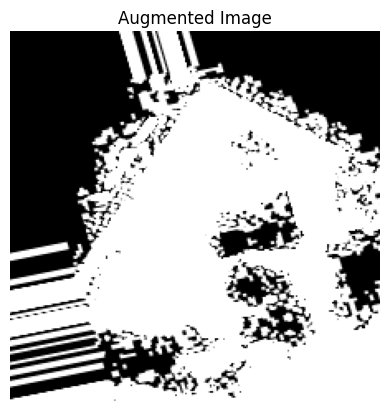

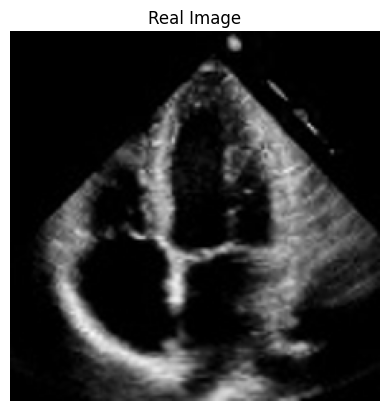

In [ ]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagenerator = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')


datagenerator.fit(images)

aug_iter = datagenerator.flow(images, batch_size=1)
augmented_image = next(aug_iter)[0]

plt.figure()
plt.imshow(augmented_image)
plt.title("Augmented Image")
plt.axis("off")


plt.figure()
plt.imshow(images[0])
plt.title("Real Image")
plt.axis("off")
plt.show()



1. visualise the augmented image with the normal image using ImageDataGenerator
2. fit the datagenerator on the images of open and closed data
3. Generate one batch of augmented images

In [ ]:

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model


from tensorflow.keras.applications import EfficientNetV2B0


eff_net_model = EfficientNetV2B0(include_top=False, weights='imagenet', input_shape= (224,224,3))


input_img = tf.keras.layers.Input(shape=(224, 224, 3), name="input_layer")
x = eff_net_model(input_img)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)


transfer_learning_model = tf.keras.Model(input_img, outputs)


In [ ]:

transfer_learning_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss= tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy'])


Training Fold 1...
Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 111s 7s/step - accuracy: 0.5520 - loss: 0.6656 - val_accuracy: 0.3409 - val_loss: 0.7860
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 49s 7s/step - accuracy: 0.8748 - loss: 0.3233 - val_accuracy: 0.8864 - val_loss: 0.4180
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 79s 8s/step - accuracy: 0.9290 - loss: 0.1993 - val_accuracy: 0.9318 - val_loss: 0.3428
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.9379 - loss: 0.1825 - val_accuracy: 0.9091 - val_loss: 0.1999
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 43s 8s/step - accuracy: 0.9511 - loss: 0.1754 - val_accuracy: 0.8864 - val_loss: 0.3954
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step


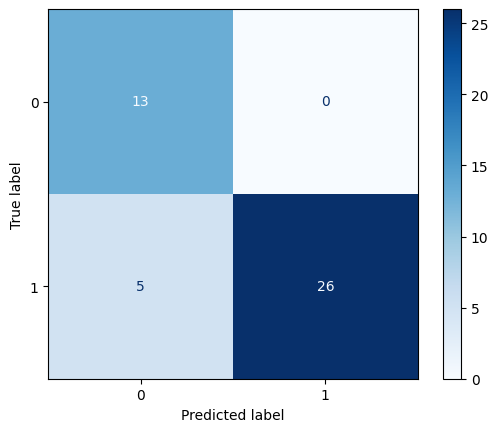

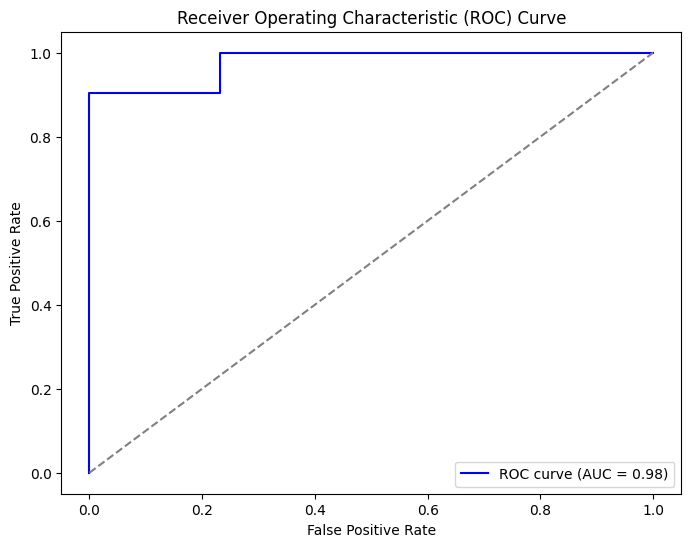


Training Fold 2...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 45s 7s/step - accuracy: 0.9370 - loss: 0.1903 - val_accuracy: 0.9091 - val_loss: 0.4204
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 42s 7s/step - accuracy: 0.9646 - loss: 0.1057 - val_accuracy: 0.9545 - val_loss: 0.0881
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 45s 8s/step - accuracy: 0.9585 - loss: 0.1172 - val_accuracy: 0.9773 - val_loss: 0.0516
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 43s 7s/step - accuracy: 0.9571 - loss: 0.1862 - val_accuracy: 0.9773 - val_loss: 0.0392
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 43s 7s/step - accuracy: 0.9705 - loss: 0.0980 - val_accuracy: 0.9773 - val_loss: 0.0411
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 498ms/step


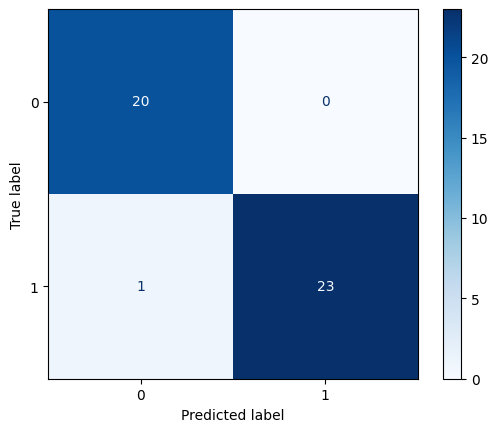

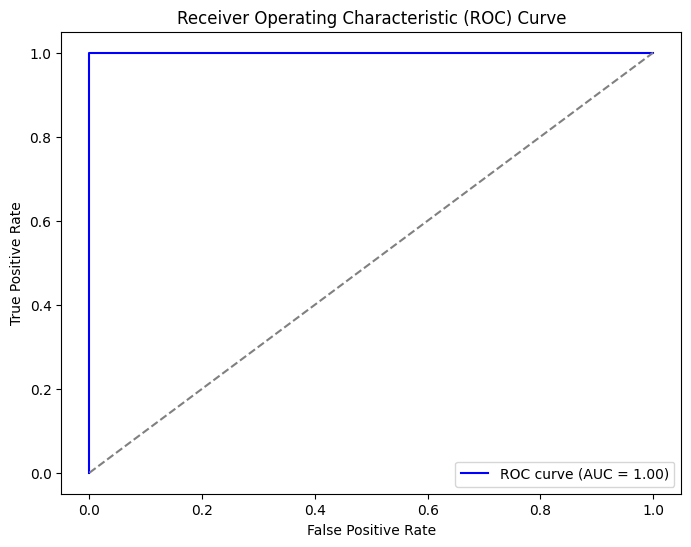


Training Fold 3...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 55s 9s/step - accuracy: 0.9681 - loss: 0.1382 - val_accuracy: 0.9773 - val_loss: 0.1358
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 44s 8s/step - accuracy: 0.9697 - loss: 0.0884 - val_accuracy: 0.9773 - val_loss: 0.1610
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 52s 9s/step - accuracy: 0.9746 - loss: 0.0780 - val_accuracy: 0.9773 - val_loss: 0.1629
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 45s 8s/step - accuracy: 0.9768 - loss: 0.0774 - val_accuracy: 0.9545 - val_loss: 0.2143
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 80s 7s/step - accuracy: 0.9636 - loss: 0.0692 - val_accuracy: 0.9318 - val_loss: 0.1915
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 512ms/step


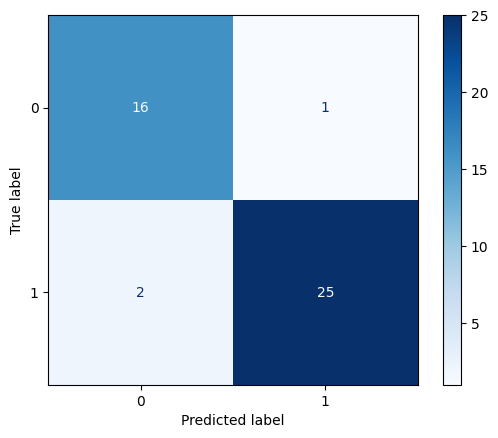

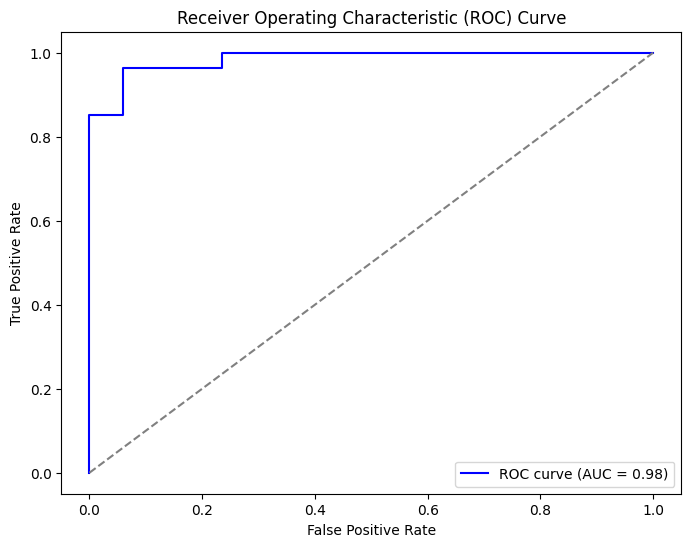


Training Fold 4...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 43s 7s/step - accuracy: 0.9588 - loss: 0.1010 - val_accuracy: 1.0000 - val_loss: 0.0178
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 43s 7s/step - accuracy: 0.9790 - loss: 0.0882 - val_accuracy: 1.0000 - val_loss: 0.0186
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 46s 8s/step - accuracy: 0.9812 - loss: 0.0408 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 43s 8s/step - accuracy: 0.9767 - loss: 0.0475 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 42s 7s/step - accuracy: 0.9918 - loss: 0.0413 - val_accuracy: 1.0000 - val_loss: 0.0028
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 526ms/step


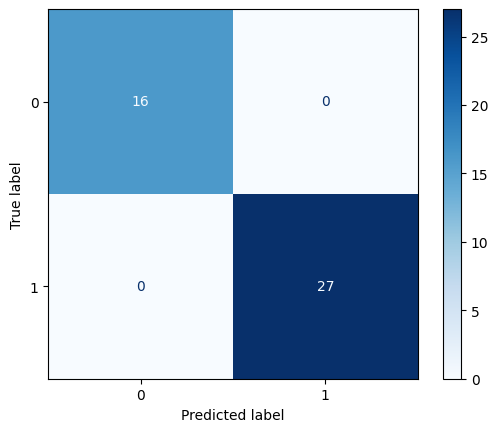

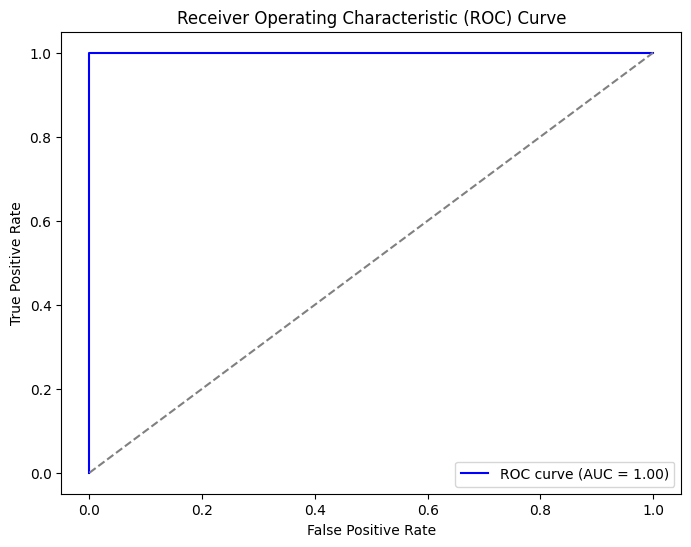


Training Fold 5...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 47s 9s/step - accuracy: 0.9957 - loss: 0.0443 - val_accuracy: 0.9767 - val_loss: 0.0551
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 78s 7s/step - accuracy: 0.9830 - loss: 0.0355 - val_accuracy: 1.0000 - val_loss: 0.0419
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 84s 8s/step - accuracy: 0.9941 - loss: 0.0300 - val_accuracy: 0.9767 - val_loss: 0.0845
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 42s 7s/step - accuracy: 0.9907 - loss: 0.0405 - val_accuracy: 0.9535 - val_loss: 0.2294
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 42s 7s/step - accuracy: 0.9649 - loss: 0.1365 - val_accuracy: 0.9535 - val_loss: 0.3778
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 464ms/step


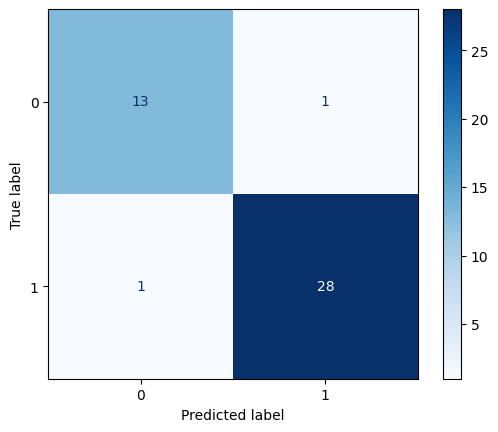

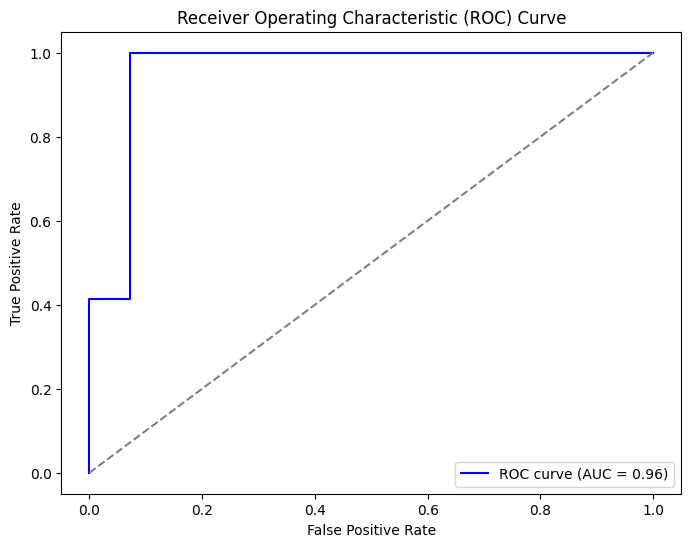

In [ ]:

import time
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt



five_fold_validation = KFold(n_splits=5, shuffle=True, random_state=42)


fold_no = 1
runtime_per_fold = []
precision_per_fold = []
recall_per_fold = []
f1_score_per_fold = []


for train_idx, val_idx in five_fold_validation.split(images):
    print(f'\nTraining Fold {fold_no}...')


    datagenerator = ImageDataGenerator(
    rotation_range=2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)


    X_train, X_val = images[train_idx], images[val_idx]
    y_train, y_val = labels[train_idx], labels[val_idx]



    datagenerator.fit(X_train)


    train_generator = datagenerator.flow(X_train, y_train, batch_size=32)

    start_time = time.time()


    history = transfer_learning_model.fit(train_generator, epochs= 5, batch_size=32, validation_data=(X_val, y_val))


    end_time = time.time()
    training_time = end_time - start_time
    runtime_per_fold.append(training_time)


    transfer_learning_predictions = transfer_learning_model.predict(X_val)
    predictions = [1 if x >= 0.5 else 0 for x in transfer_learning_predictions]


    from sklearn.metrics import precision_score,recall_score,f1_score,confusion_matrix,roc_curve,auc,ConfusionMatrixDisplay
    tl_model_recall = round(recall_score(y_val,predictions),2)
    tl_model_f1_score = round(f1_score(y_val,predictions),2)
    tl_model_precision = round(precision_score(y_val,predictions),2)
    transfer_learning_confusion_matrix = confusion_matrix(y_val,predictions)


    precision_per_fold.append(tl_model_precision)
    recall_per_fold.append(tl_model_recall)
    f1_score_per_fold.append(tl_model_precision)


    display_cm = ConfusionMatrixDisplay(confusion_matrix=transfer_learning_confusion_matrix, display_labels=[0, 1])
    display_cm.plot(cmap='Blues')
    plt.show()


    false_positive_rate, true_positive_rate, _ = roc_curve(y_val, transfer_learning_predictions)
    roc_auc = auc(false_positive_rate, true_positive_rate)


    plt.figure(figsize=(8, 6))
    plt.plot(false_positive_rate, true_positive_rate, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.show()
    fold_no += 1

# **Performance evaluation**

In [ ]:
avg_runtime = np.mean(runtime_per_fold)
avg_precision = np.mean(precision_per_fold)
avg_recall = np.mean(recall_per_fold)
avg_f1_score = np.mean(f1_score_per_fold)

In [ ]:
print(f'the average precision for 5 fold validation is {avg_precision:.2f}')
print(f'the average runtime for 5 fold validation is {avg_runtime:.2f}')
print(f'the average recall for 5 fold validation is {avg_recall:.2f}')
print(f'the average f1_score for 5 fold validation is {avg_f1_score:.2f}')

the average precision for 5 fold validation is 0.99
the average runtime for 5 fold validation is 283.99
the average recall for 5 fold validation is 0.94
the average f1_score for 5 fold validation is 0.99


**Conclusion from task 3**







As observed from the above result after using transfer learing. The pricision,recall and f1_score are much better.Hence using data augmentation and transfer learning we are able to achieve better results.

Time consuming for execution.

Will be a problem in real world scenarios in the problem determination.

# **Bonus task**


In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate
from tensorflow.keras.optimizers import Adam


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving 1.tiff to 1.tiff


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving 1.jpg to 1.jpg


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving 1.jpg to 1 (1).jpg


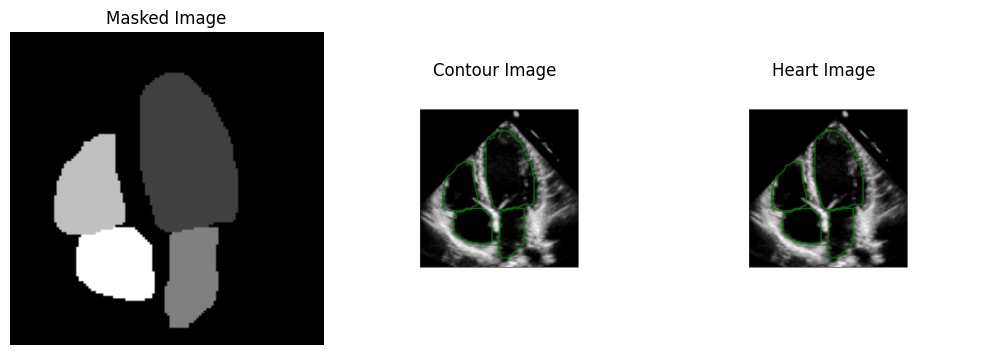

In [ ]:
import cv2
import matplotlib.pyplot as plt


img_masked = cv2.imread('1.tiff')
img_contour = cv2.imread('1.jpg')
img_heart = cv2.imread('1.jpg')


img_masked_rgb = cv2.cvtColor(img_masked, cv2.COLOR_BGR2RGB)
img_contour_rgb = cv2.cvtColor(img_contour, cv2.COLOR_BGR2RGB)
img_heart_rgb = cv2.cvtColor(img_heart, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(10, 10))

plt.subplot(1, 3, 1)
plt.imshow(img_masked_rgb)
plt.title('Masked Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_contour_rgb)
plt.title('Contour Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_heart_rgb)
plt.title('Heart Image')
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split


image_dir = '/content/drive/MyDrive/ds-1/heart/heart_images'
mask_dir = '/content/drive/MyDrive/data science course work/data_cw/data/heart/various/masks'


image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))



In [ ]:

img_height = 256
img_width = 256


def preprocess_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (img_width, img_height))
    image = image / 255.0
    return image


def preprocess_mask(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (img_width, img_height))
    mask = mask / 255.0
    return mask

In [ ]:

images = np.array([preprocess_image(os.path.join(image_dir, img)) for img in image_files])
masks = np.array([preprocess_mask(os.path.join(mask_dir, mask)) for mask in mask_files])


images = np.expand_dims(images, axis=-1)
masks = np.expand_dims(masks, axis=-1)

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(images, masks, test_size=0.2, random_state=42)


X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_test_rgb = np.repeat(X_test, 3, axis=-1)

In [ ]:
from tensorflow.keras.utils import to_categorical


num_classes = 4


y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)


In [ ]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate

inputs = Input((256, 256, 3))


conv1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
pool1 = MaxPooling2D()(conv1)

conv2 = Conv2D(64, 3, activation='relu', padding='same')(pool1)
up1 = UpSampling2D()(conv2)

concat1 = concatenate([conv1, up1])
outputs = Conv2D(4, 1, activation='softmax')(concat1)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
model.fit(X_train_rgb, y_train_cat,batch_size=8,epochs=10)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.7463 - loss: 1.2477
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.9537 - loss: 0.5727
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9536 - loss: 0.2858
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9538 - loss: 0.2171
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.9540 - loss: 0.1932
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9532 - loss: 0.1863
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9526 - loss: 0.1844
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9536 - loss: 0.1802
Epoch 9/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.9523 - loss: 0.1830
Epoch 10/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9533 - loss: 0.1795


In [ ]:

loss, accuracy = model.evaluate(X_test_rgb, y_test_cat)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9526 - loss: 0.1807
Test Loss: 0.1791013777256012
Test Accuracy: 0.953216552734375


In [ ]:

preds = model.predict(X_test_rgb)


preds_labels = np.argmax(preds, axis=-1)
y_test_labels = np.argmax(y_test_cat, axis=-1)


2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 987ms/step


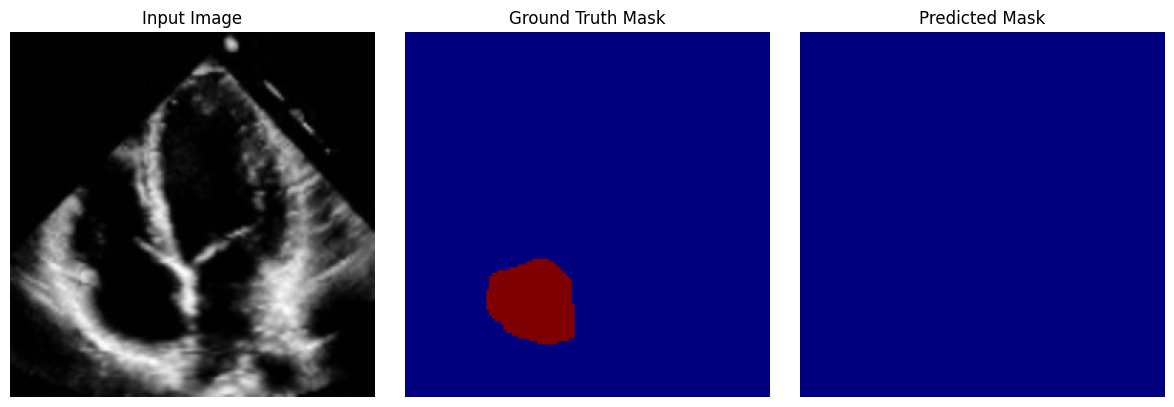

In [ ]:
import matplotlib.pyplot as plt

def display_prediction(index):
    plt.figure(figsize=(12, 4))


    original = X_test[index, :, :, 0]


    mask = y_test_labels[index]


    pred = preds_labels[index]

    titles = ['Input Image', 'Ground Truth Mask', 'Predicted Mask']
    images = [original, mask, pred]

    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.imshow(images[i], cmap='gray' if i == 0 else 'jet')
        plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()


display_prediction(0)


# **References**
Task 1 -Heart and Non-Heart Classification

1.SVM- Self
2.Vanilla CNN- Lecture Notes

Task 2 -Open and close heart Segmentation

1.SVM- self

Task 3- Image Augmentation and Transfer learning

1.Google search

Bonus task- Implementation of Unet

1.Google search

